In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

In [ ]:
df = pd.read_csv('customer_service_interactions.csv')
print(f'Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded successfully: 10000 rows, 13 columns


In [ ]:
df.head(10)

,interaction_id,timestamp,query_type,handled_by,response_time_min,resolution_status,customer_sentiment,customer_satisfaction,interaction_cost_usd,customer_id,region,device_type,follow_up_required
0,d3053ddd-7ea3-447d-9c52-2d2e14ff40fe,2024-04-12,Billing Question,AI Chatbot,1.88,Resolved,0.12,3,2.81,06f211ac-4d8e-4a98-988c-be2d96c45b2f,Delaware,Mobile,False
1,4a2c75d4-8687-4350-a595-f15e82720fbd,2024-04-26,Password Reset,AI Chatbot,1.09,Resolved,0.14,4,0.13,bad3cd0f-24e7-4999-8e76-ccd77483db4e,Hawaii,Tablet,False
2,e9f26019-4e13-4470-8068-81a4dfa5cf83,2024-02-18,Shipping Inquiry,AI Chatbot,1.13,Pending,0.26,2,2.75,fd882d13-6f84-4969-b36a-9958b58b2380,Maryland,Mobile,False
3,b6e712b5-aa16-4ff0-a9cd-90f3cb11fe84,2024-04-17,Account Update,AI Chatbot,1.12,Resolved,0.33,3,4.42,fba76a29-dd57-4cfa-98a5-ce9d7f3c82f7,Connecticut,Mobile,True
4,5c6ca2ba-8c3d-4567-a336-5c0bb6e0978d,2024-03-24,Billing Question,Human Agent,9.85,Escalated,0.87,2,5.26,daee835d-3f72-493e-beff-b2026da9ab53,Mississippi,Mobile,True
5,bdf5a660-d280-4312-ae37-953b1cc17b65,2024-05-11,Billing Question,Human Agent,15.33,Resolved,0.76,4,7.26,c04a95fa-00cd-42fe-9828-c4ad7d9e5d7b,Nebraska,Tablet,True
6,2da13fcc-4577-4379-b1ca-6e3f025fe562,2024-02-09,Technical Support,AI Chatbot,1.68,Resolved,0.79,4,3.63,ee09989b-9cac-414f-8a58-9e138ef257c3,South Dakota,Mobile,False
7,93243216-d728-462f-98af-cde3f29a1163,2024-06-05,Technical Support,AI Chatbot,1.03,Resolved,0.48,4,4.33,591b93cd-3a1f-40d2-9f48-1a0f3c546817,Hawaii,Desktop,False
8,13a2adf0-1e52-47aa-b155-c2ad7f9da8d1,2024-02-02,Password Reset,AI Chatbot,1.65,Pending,0.48,2,4.75,db9a0c54-a83c-4ed8-98af-5e00a01dd389,Maine,Mobile,True
9,c92c6469-90dc-4657-8770-2c728a30b02d,2024-05-30,Password Reset,AI Chatbot,2.17,Resolved,0.82,2,4.60,8de77c46-9606-4f6d-84f8-eda18e819c42,Vermont,Mobile,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   interaction_id         10000 non-null  object 
 1   timestamp              10000 non-null  object 
 2   query_type             10000 non-null  object 
 3   handled_by             10000 non-null  object 
 4   response_time_min      10000 non-null  float64
 5   resolution_status      10000 non-null  object 
 6   customer_sentiment     10000 non-null  float64
 7   customer_satisfaction  10000 non-null  int64  
 8   interaction_cost_usd   10000 non-null  float64
 9   customer_id            10000 non-null  object 
 10  region                 10000 non-null  object 
 11  device_type            10000 non-null  object 
 12  follow_up_required     10000 non-null  bool   
dtypes: bool(1), float64(3), int64(1), object(8)
memory usage: 947.4+ KB


In [ ]:
df.describe()

,response_time_min,customer_sentiment,customer_satisfaction,interaction_cost_usd
count,10000.000000,10000.000000,10000.00000,10000.000000
mean,4.302933,0.350261,3.28630,5.022155
std,3.482249,0.296517,1.00858,2.504918
min,0.200000,-0.750000,1.00000,-2.640000
25%,1.450000,0.150000,3.00000,3.010000
50%,2.550000,0.350000,3.00000,5.040000
75%,7.072500,0.550000,4.00000,7.040000
max,17.150000,1.000000,5.00000,12.890000


In [ ]:
print('Column Names:')
for col in df.columns:
    print(f'  - {col}')

Column Names:
  - interaction_id
  - timestamp
  - query_type
  - handled_by
  - response_time_min
  - resolution_status
  - customer_sentiment
  - customer_satisfaction
  - interaction_cost_usd
  - customer_id
  - region
  - device_type
  - follow_up_required


##  Data Quality Assessment

In [ ]:
missing_values = df.isnull().sum()
print('Missing Values:')
print(missing_values[missing_values > 0])
print(f'\nTotal missing values: {missing_values.sum()}')

Missing Values:
Series([], dtype: int64)

Total missing values: 0


In [ ]:
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicate_count}')

Number of duplicate rows: 0


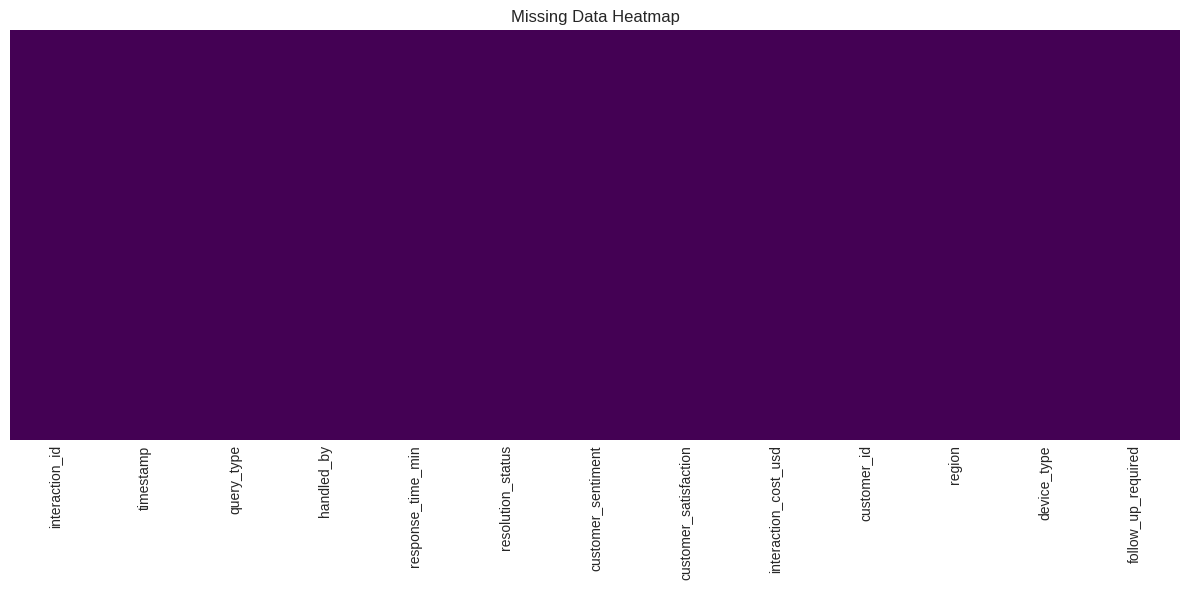

In [ ]:
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Data Heatmap')
plt.tight_layout()
plt.show()

#Univariate Analysis

In [ ]:
categorical_cols = ['query_type', 'handled_by', 'resolution_status', 'device_type', 'region', 'follow_up_required']
for col in categorical_cols:
    print(f'\n{col}:')
    print(df[col].value_counts())


query_type:
query_type
Billing Question       1725
Product Information    1725
Account Update         1673
Password Reset         1632
Shipping Inquiry       1625
Technical Support      1620
Name: count, dtype: int64

handled_by:
handled_by
Human Agent    5049
AI Chatbot     4951
Name: count, dtype: int64

resolution_status:
resolution_status
Resolved     7481
Escalated    1794
Pending       725
Name: count, dtype: int64

device_type:
device_type
Tablet     3364
Desktop    3354
Mobile     3282
Name: count, dtype: int64

region:
region
Florida           226
Oregon            225
Minnesota         221
California        221
Arkansas          219
Kentucky          214
Vermont           214
Hawaii            213
Tennessee         213
Wyoming           213
Arizona           212
Oklahoma          211
Pennsylvania      211
Washington        211
Montana           211
Delaware          210
Mississippi       210
South Carolina    209
New York          207
Kansas            206
New Mexico        

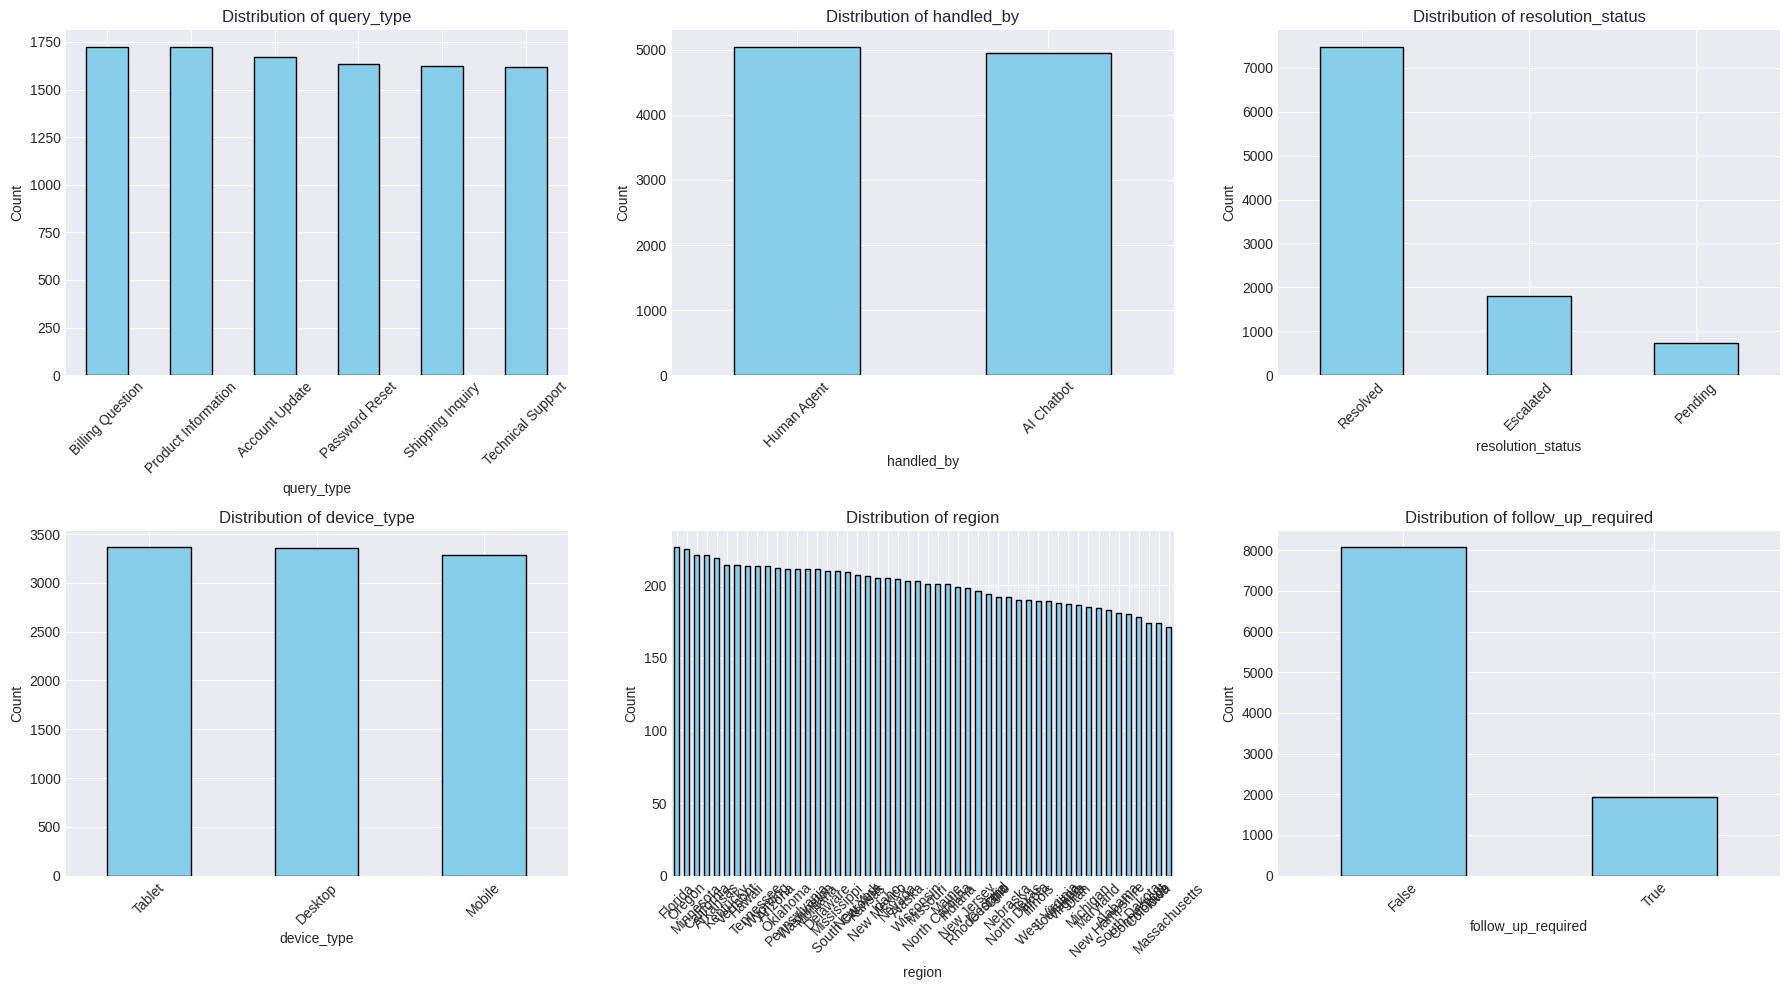

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


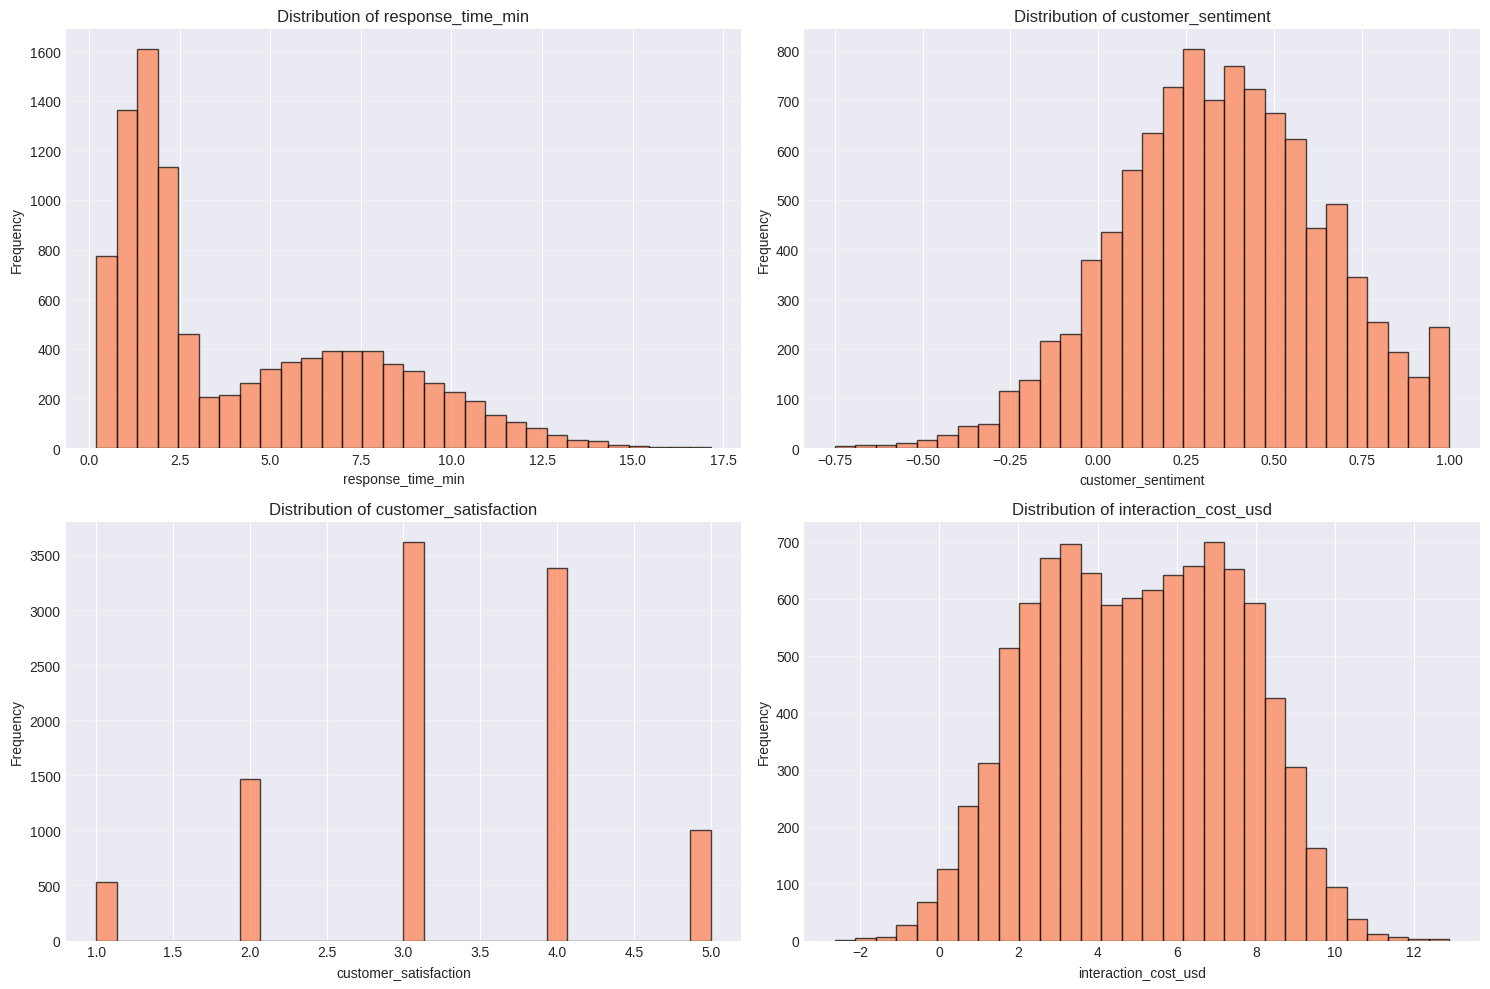

In [ ]:
numerical_cols = ['response_time_min', 'customer_sentiment', 'customer_satisfaction', 'interaction_cost_usd']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


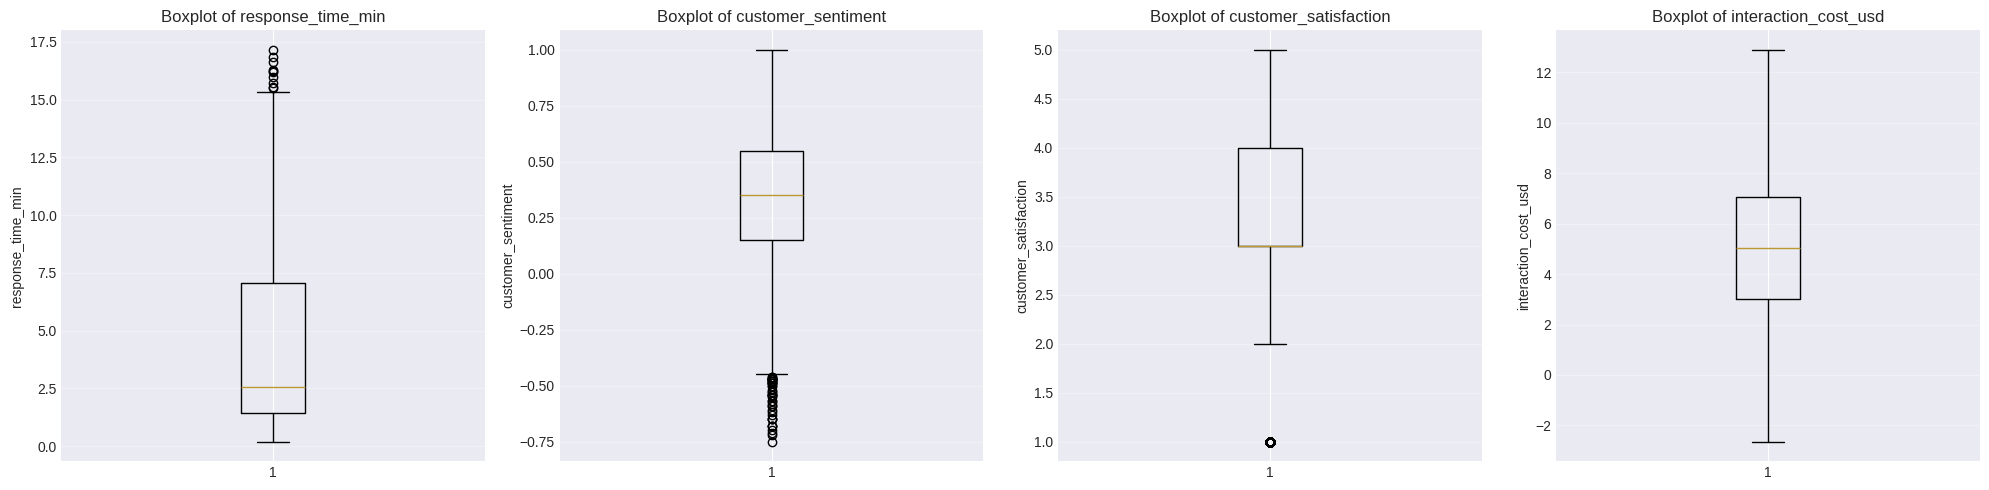

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(df[col], vert=True)
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#Bivariate Analysis

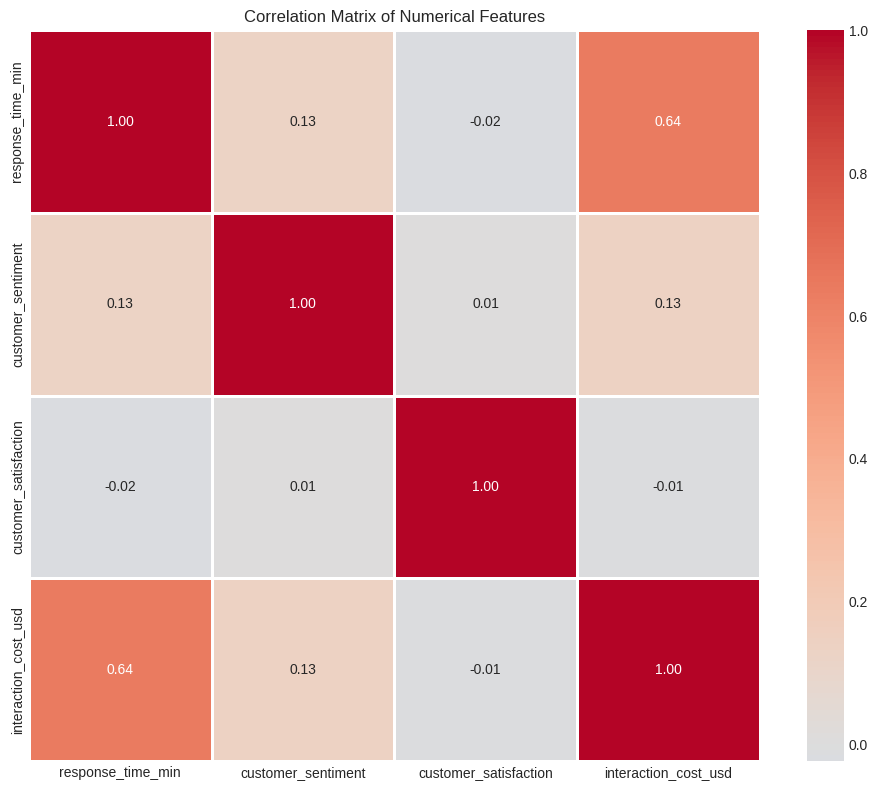

In [ ]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

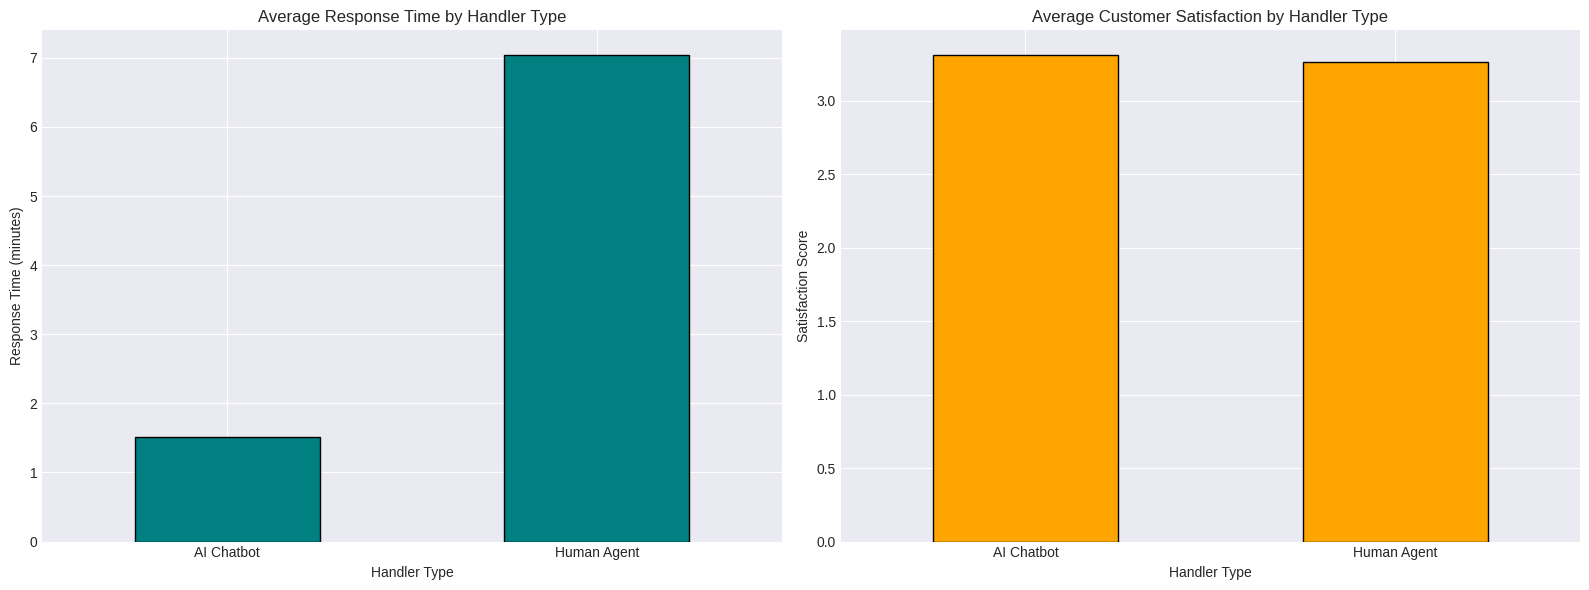

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

df.groupby('handled_by')['response_time_min'].mean().plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Average Response Time by Handler Type')
axes[0].set_ylabel('Response Time (minutes)')
axes[0].set_xlabel('Handler Type')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('handled_by')['customer_satisfaction'].mean().plot(kind='bar', ax=axes[1], color='orange', edgecolor='black')
axes[1].set_title('Average Customer Satisfaction by Handler Type')
axes[1].set_ylabel('Satisfaction Score')
axes[1].set_xlabel('Handler Type')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

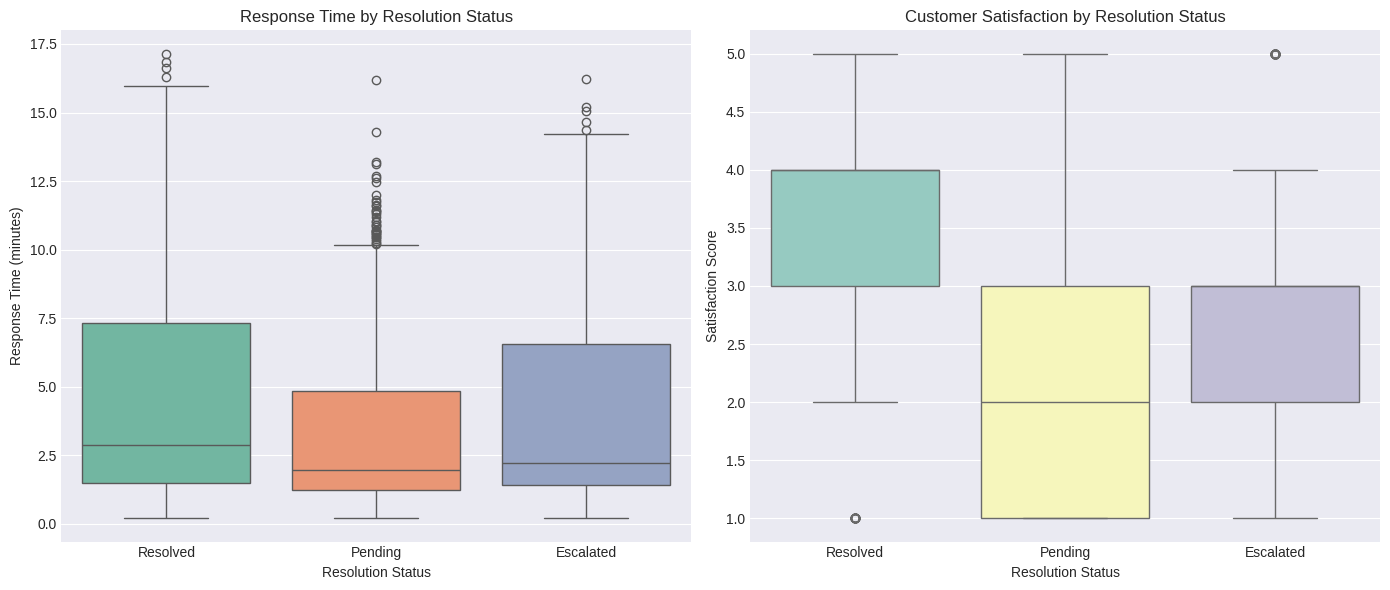

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='resolution_status', y='response_time_min', palette='Set2')
plt.title('Response Time by Resolution Status')
plt.xlabel('Resolution Status')
plt.ylabel('Response Time (minutes)')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='resolution_status', y='customer_satisfaction', palette='Set3')
plt.title('Customer Satisfaction by Resolution Status')
plt.xlabel('Resolution Status')
plt.ylabel('Satisfaction Score')

plt.tight_layout()
plt.show()


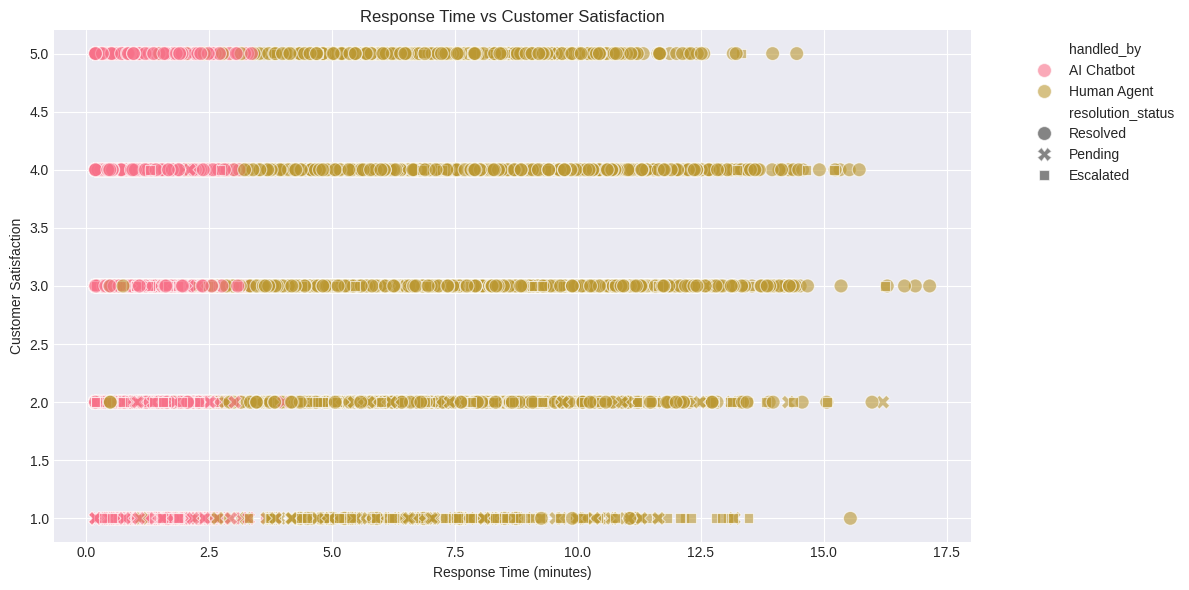

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='response_time_min', y='customer_satisfaction',
                hue='handled_by', style='resolution_status', s=100, alpha=0.6)
plt.title('Response Time vs Customer Satisfaction')
plt.xlabel('Response Time (minutes)')
plt.ylabel('Customer Satisfaction')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

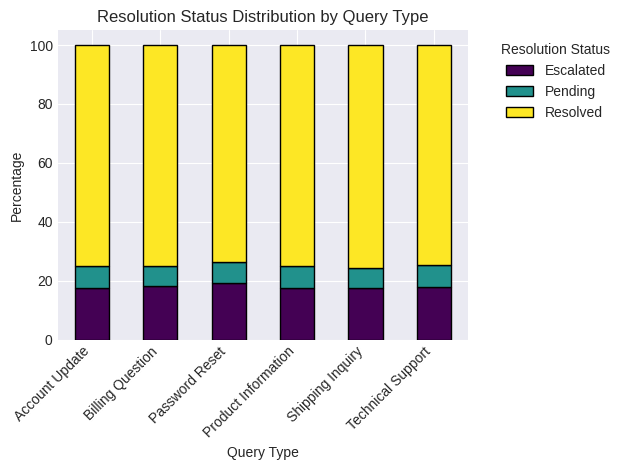

In [ ]:
query_resolution = pd.crosstab(df['query_type'], df['resolution_status'], normalize='index') * 100

plt.figure(figsize=(12, 6))
query_resolution.plot(kind='bar', stacked=True, colormap='viridis', edgecolor='black')
plt.title('Resolution Status Distribution by Query Type')
plt.xlabel('Query Type')
plt.ylabel('Percentage')
plt.legend(title='Resolution Status', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#Feature Engineering

In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['day_name'] = df['timestamp'].dt.day_name()

print('New time-based features created:')
print(df[['timestamp', 'year', 'month', 'day_of_week', 'day_name']].head())

New time-based features created:
   timestamp  year  month  day_of_week   day_name
0 2024-04-12  2024      4            4     Friday
1 2024-04-26  2024      4            4     Friday
2 2024-02-18  2024      2            6     Sunday
3 2024-04-17  2024      4            2  Wednesday
4 2024-03-24  2024      3            6     Sunday


In [ ]:
df['is_high_cost'] = df['interaction_cost_usd'] > df['interaction_cost_usd'].median()
df['is_satisfied'] = df['customer_satisfaction'] >= 4
df['is_positive_sentiment'] = df['customer_sentiment'] > 0
df['response_category'] = pd.cut(df['response_time_min'], bins=[0, 2, 5, 10, 20],
                                   labels=['Fast', 'Moderate', 'Slow', 'Very Slow'])

print('Categorical features created:')
print(df[['is_high_cost', 'is_satisfied', 'is_positive_sentiment', 'response_category']].head())

Categorical features created:
   is_high_cost  is_satisfied  is_positive_sentiment response_category
0         False         False                   True              Fast
1         False          True                   True              Fast
2         False         False                   True              Fast
3         False         False                   True              Fast
4          True         False                   True              Slow


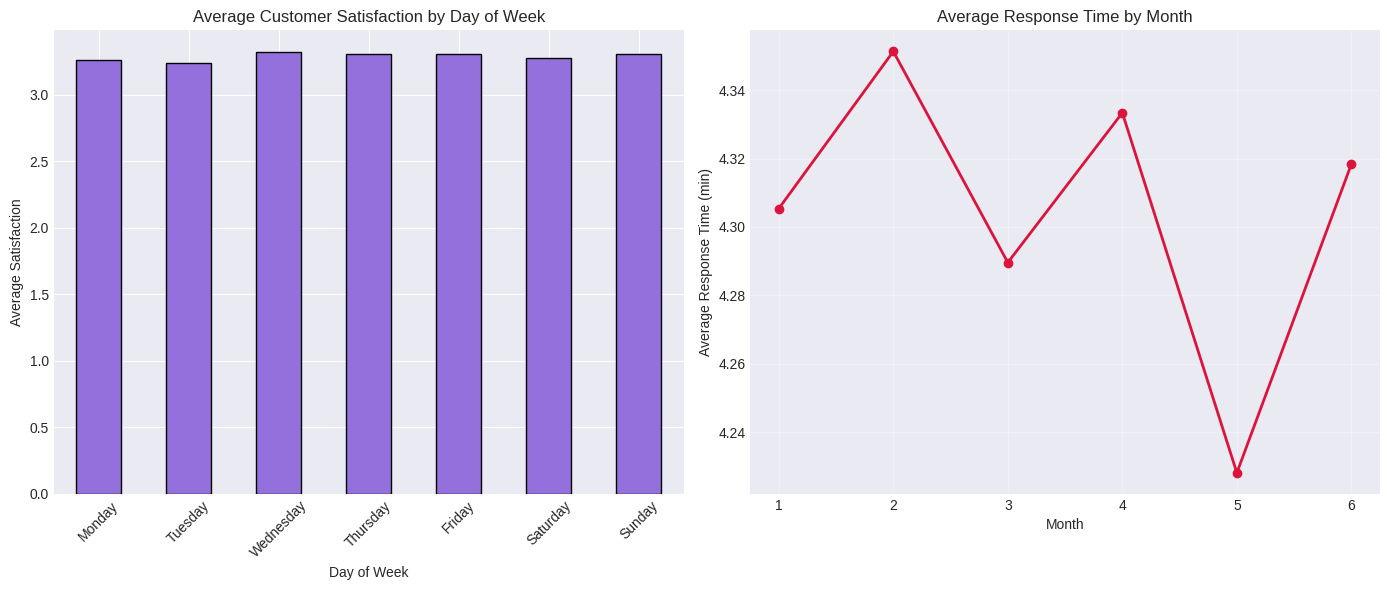

In [ ]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
df.groupby('day_name')['customer_satisfaction'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
).plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Average Customer Satisfaction by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Satisfaction')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
df.groupby('month')['response_time_min'].mean().plot(kind='line', marker='o', color='crimson', linewidth=2)
plt.title('Average Response Time by Month')
plt.xlabel('Month')
plt.ylabel('Average Response Time (min)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


#Outlier Detection and Treatment

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

for col in numerical_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f'\n{col}:')
    print(f'  Lower bound: {lower:.2f}')
    print(f'  Upper bound: {upper:.2f}')
    print(f'  Number of outliers: {len(outliers)}')


response_time_min:
  Lower bound: -6.98
  Upper bound: 15.51
  Number of outliers: 10

customer_sentiment:
  Lower bound: -0.45
  Upper bound: 1.15
  Number of outliers: 43

customer_satisfaction:
  Lower bound: 1.50
  Upper bound: 5.50
  Number of outliers: 531

interaction_cost_usd:
  Lower bound: -3.04
  Upper bound: 13.09
  Number of outliers: 0


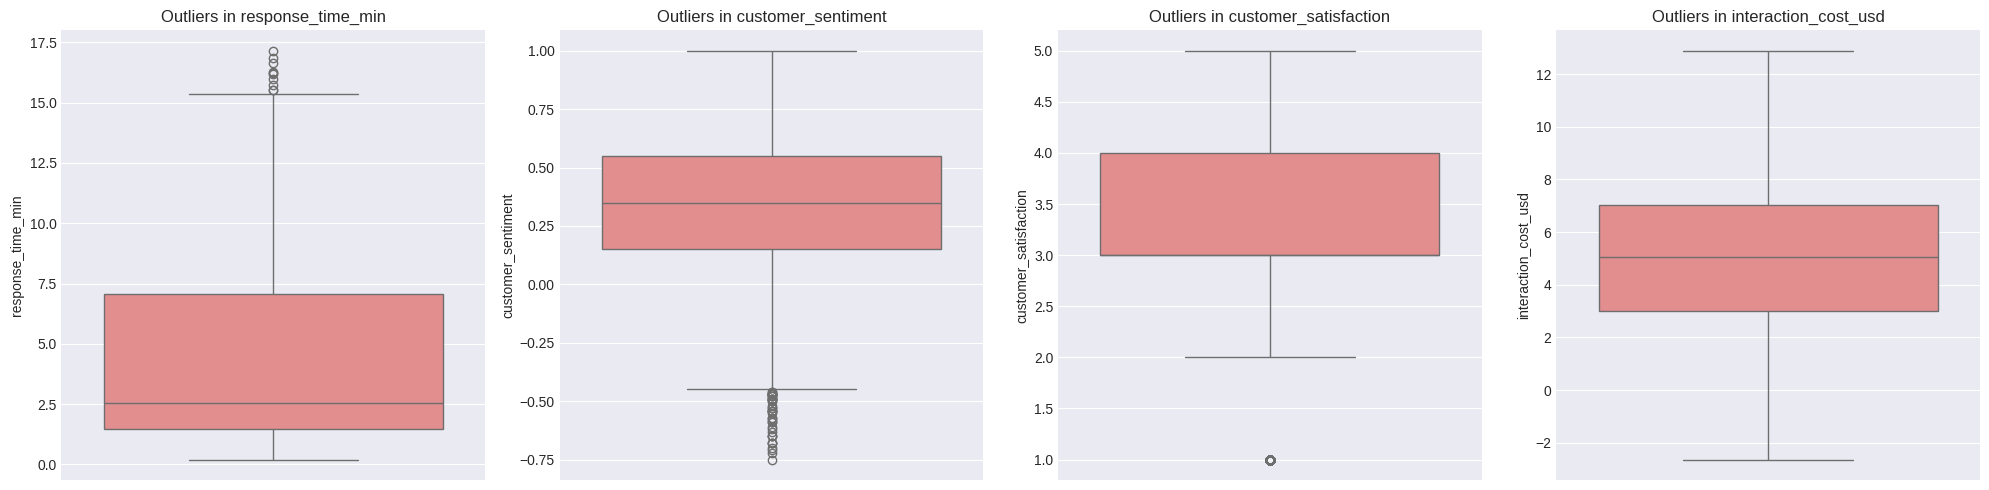

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for idx, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[idx], color='lightcoral')
    axes[idx].set_title(f'Outliers in {col}')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()


#Data Preprocessing for Modeling

In [ ]:
df_model = df.copy()

label_encoders = {}
categorical_features = ['query_type', 'handled_by', 'resolution_status', 'device_type', 'region']

for col in categorical_features:
    le = LabelEncoder()
    df_model[f'{col}_encoded'] = le.fit_transform(df_model[col])
    label_encoders[col] = le

print('Encoded features created:')
print(df_model[[col for col in df_model.columns if '_encoded' in col]].head())

Encoded features created:
   query_type_encoded  handled_by_encoded  resolution_status_encoded  \
0                   1                   0                          2   
1                   2                   0                          2   
2                   4                   0                          1   
3                   0                   0                          2   
4                   1                   1                          0   

   device_type_encoded  region_encoded  
0                    1               7  
1                    2              10  
2                    1              19  
3                    1               6  
4                    1              23  


In [ ]:
df_model['follow_up_required'] = df_model['follow_up_required'].astype(int)

feature_cols = ['response_time_min', 'customer_sentiment', 'interaction_cost_usd',
                'query_type_encoded', 'handled_by_encoded', 'resolution_status_encoded',
                'device_type_encoded', 'month', 'day_of_week', 'follow_up_required']

scaler = StandardScaler()
df_model[feature_cols] = scaler.fit_transform(df_model[feature_cols])

print('Features scaled successfully')
print(df_model[feature_cols].describe())

Features scaled successfully
       response_time_min  customer_sentiment  interaction_cost_usd  \
count       1.000000e+04        1.000000e+04          1.000000e+04   
mean       -9.521273e-17        3.872458e-17         -2.344791e-16   
std         1.000050e+00        1.000050e+00          1.000050e+00   
min        -1.178301e+00       -3.710805e+00         -3.058998e+00   
25%        -8.193198e-01       -6.754121e-01         -8.033220e-01   
50%        -5.034162e-01       -8.802640e-04          7.124343e-03   
75%         7.953783e-01        6.736516e-01          8.055937e-01   
max         3.689486e+00        2.191348e+00          3.141117e+00   

       query_type_encoded  handled_by_encoded  resolution_status_encoded  \
count        1.000000e+04        1.000000e+04               1.000000e+04   
mean         6.252776e-17       -4.263256e-18              -4.902745e-17   
std          1.000050e+00        1.000050e+00               1.000050e+00   
min         -1.455386e+00       -1.0

#Feature Selection and Importance

In [ ]:
X = df_model[feature_cols]
y = df_model['customer_satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

print('Feature Importance:')
print(feature_importance)

Feature Importance:
                     feature  importance
5  resolution_status_encoded    0.248696
0          response_time_min    0.182117
2       interaction_cost_usd    0.178878
1         customer_sentiment    0.152525
8                day_of_week    0.064642
7                      month    0.059127
3         query_type_encoded    0.058557
6        device_type_encoded    0.034362
9         follow_up_required    0.016502
4         handled_by_encoded    0.004594


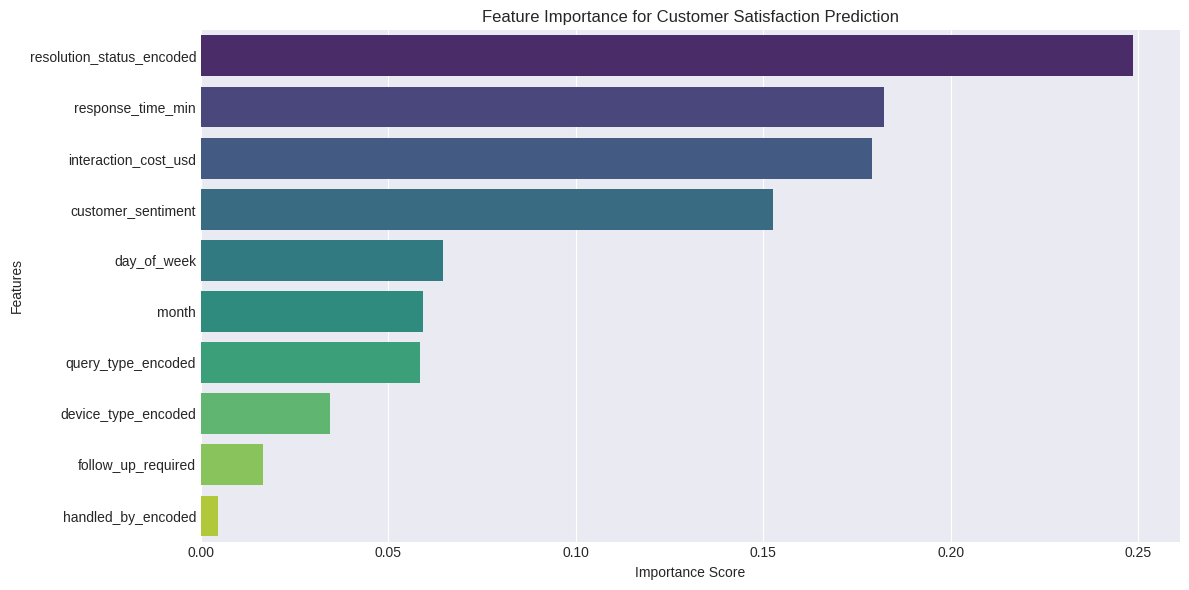

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance for Customer Satisfaction Prediction')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

#Linear Regression Model

In [ ]:
X = df_model[feature_cols]
y = df_model['customer_satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print('Linear Regression Results:')
print(f'Mean Squared Error: {mse_lr:.4f}')
print(f'R-squared Score: {r2_lr:.4f}')

Linear Regression Results:
Mean Squared Error: 0.7721
R-squared Score: 0.2056


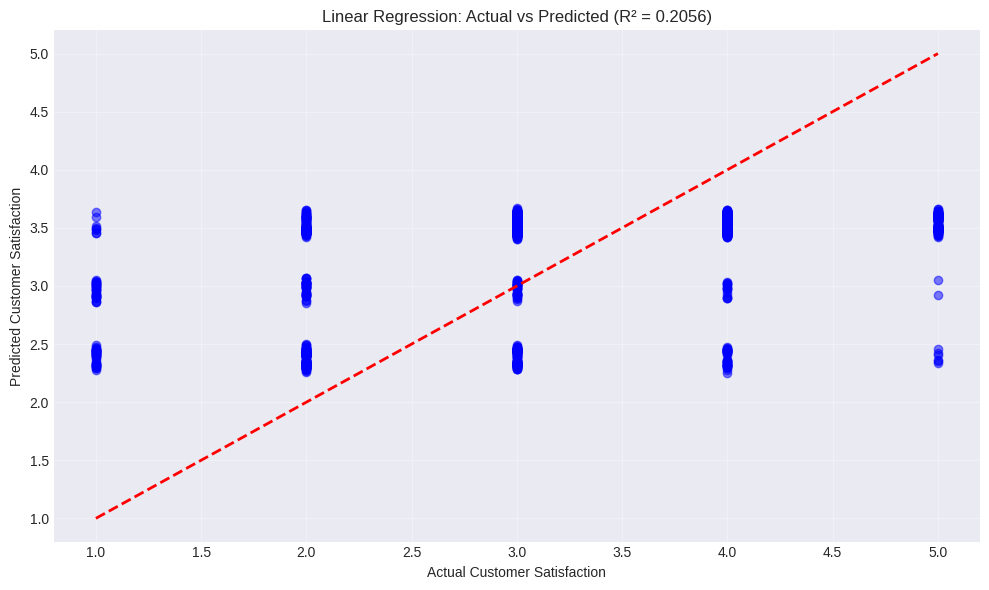

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Customer Satisfaction')
plt.ylabel('Predicted Customer Satisfaction')
plt.title(f'Linear Regression: Actual vs Predicted (R² = {r2_lr:.4f})')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Logistic Regression for Classification

In [ ]:
X = df_model[feature_cols]
y_binary = df_model['is_satisfied']

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print('Logistic Regression Results:')
print(f'Accuracy: {accuracy_log:.4f}')
print(f'Precision: {precision_log:.4f}')
print(f'Recall: {recall_log:.4f}')
print(f'F1-Score: {f1_log:.4f}')

Logistic Regression Results:
Accuracy: 0.6380
Precision: 0.5756
Recall: 0.5525
F1-Score: 0.5639


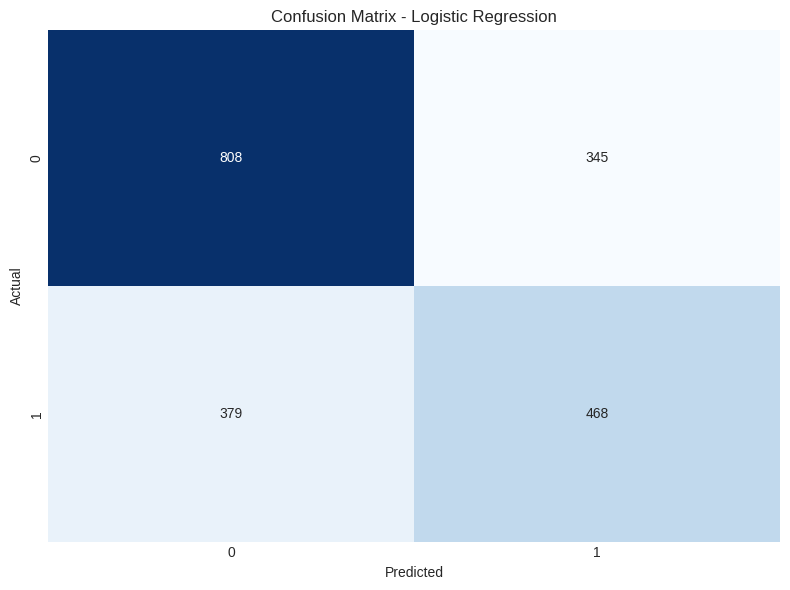

In [ ]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

#Decision Tree Classifier

In [ ]:
X = df_model[feature_cols]
y_binary = df_model['is_satisfied']

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(max_depth=5, min_samples_split=50, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print('Decision Tree Results:')
print(f'Accuracy: {accuracy_dt:.4f}')
print(f'Precision: {precision_dt:.4f}')
print(f'Recall: {recall_dt:.4f}')
print(f'F1-Score: {f1_dt:.4f}')

Decision Tree Results:
Accuracy: 0.6380
Precision: 0.5922
Recall: 0.4664
F1-Score: 0.5218


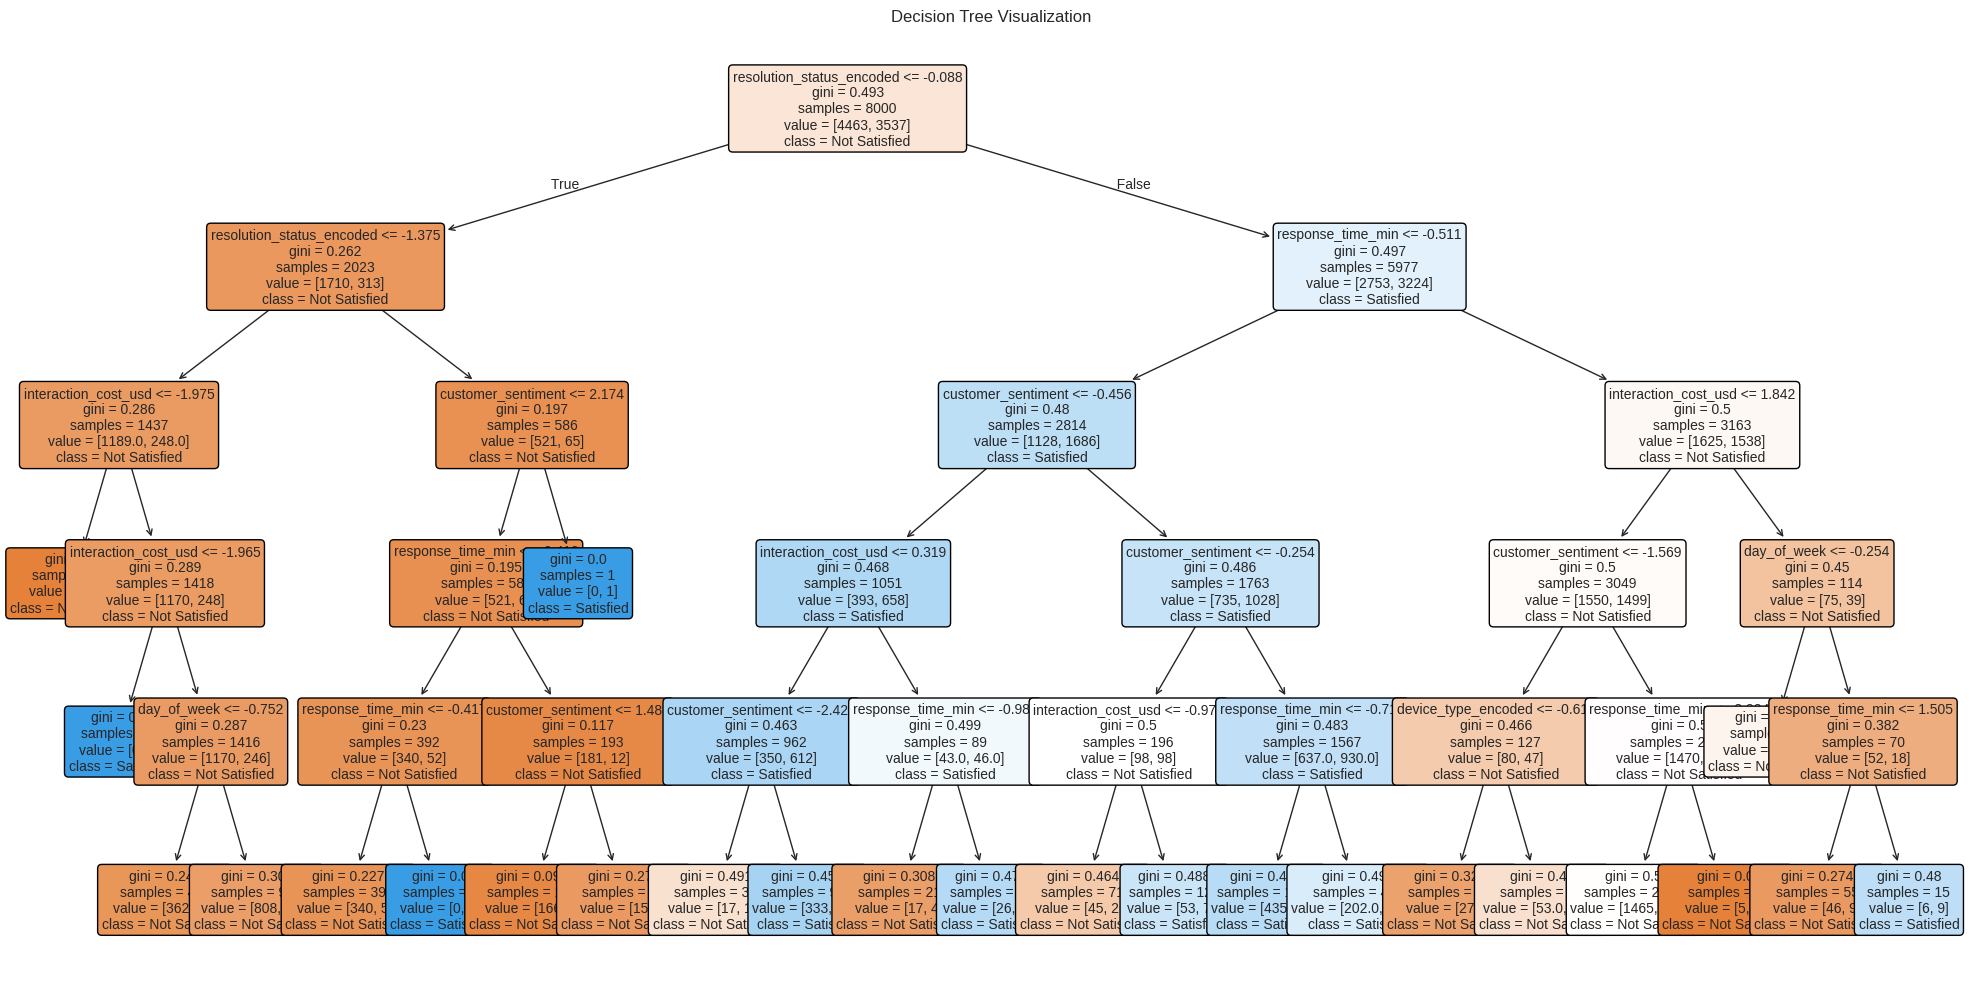

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=feature_cols, class_names=['Not Satisfied', 'Satisfied'],
          filled=True, rounded=True, fontsize=10)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()


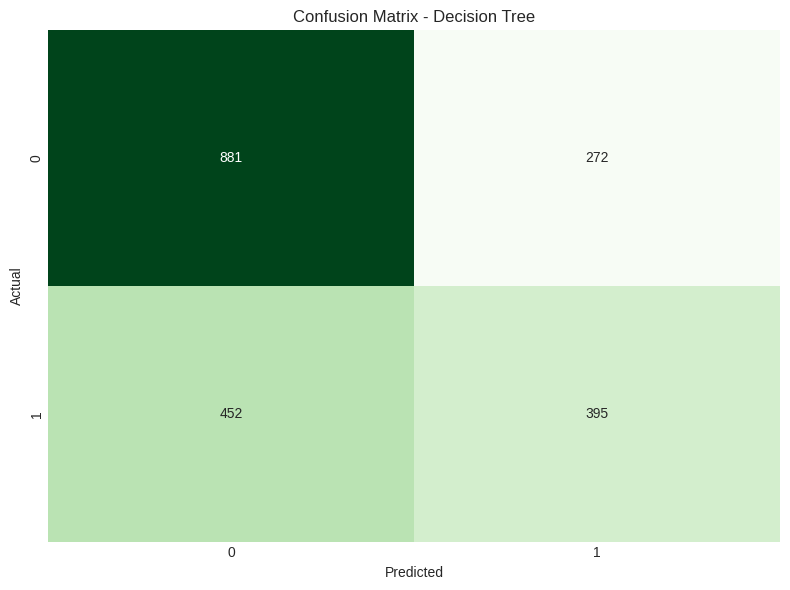

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

#Random Forest Classifier

In [ ]:
X = df_model[feature_cols]
y_binary = df_model['is_satisfied']

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print('Random Forest Results:')
print(f'Accuracy: {accuracy_rf:.4f}')
print(f'Precision: {precision_rf:.4f}')
print(f'Recall: {recall_rf:.4f}')
print(f'F1-Score: {f1_rf:.4f}')


Random Forest Results:
Accuracy: 0.6345
Precision: 0.5586
Recall: 0.6529
F1-Score: 0.6021


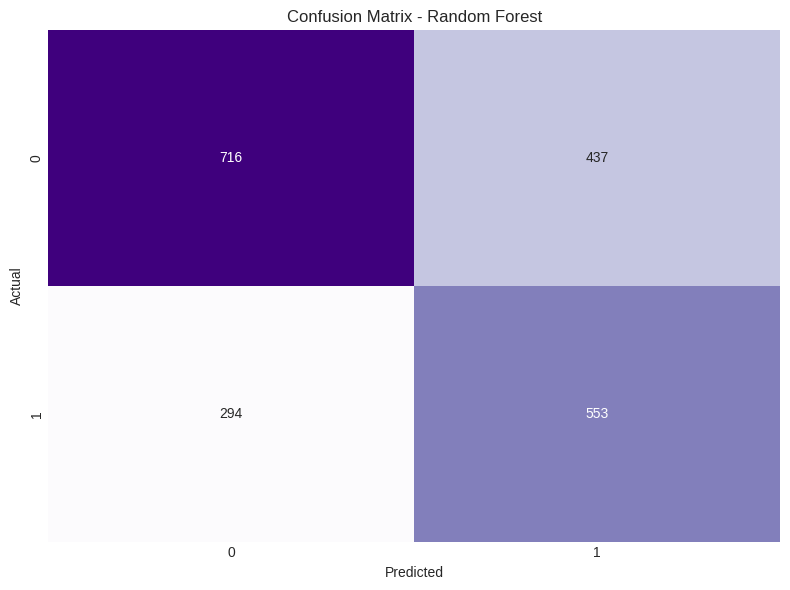

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


#Naive Bayes Classifier

In [ ]:
X = df_model[feature_cols]
y_binary = df_model['is_satisfied']

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print('Naive Bayes Results:')
print(f'Accuracy: {accuracy_nb:.4f}')
print(f'Precision: {precision_nb:.4f}')
print(f'Recall: {recall_nb:.4f}')
print(f'F1-Score: {f1_nb:.4f}')


Naive Bayes Results:
Accuracy: 0.6015
Precision: 0.5167
Recall: 0.9115
F1-Score: 0.6595


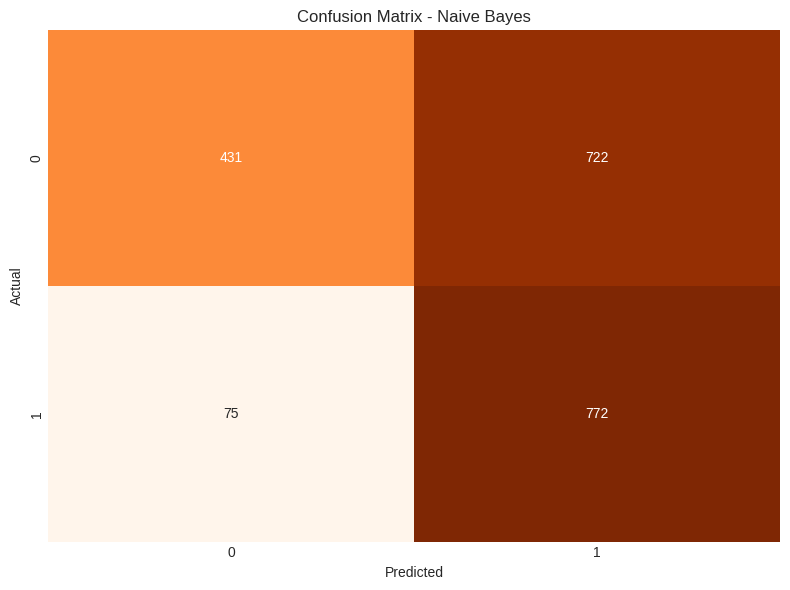

In [ ]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


#Model Performance Comparison




In [ ]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes'],
    'Accuracy': [accuracy_log, accuracy_dt, accuracy_rf, accuracy_nb],
    'Precision': [precision_log, precision_dt, precision_rf, precision_nb],
    'Recall': [recall_log, recall_dt, recall_rf, recall_nb],
    'F1-Score': [f1_log, f1_dt, f1_rf, f1_nb]
})

print('Model Performance Comparison:')
print(model_comparison)

Model Performance Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression    0.6380   0.575646  0.552538  0.563855
1        Decision Tree    0.6380   0.592204  0.466352  0.521797
2        Random Forest    0.6345   0.558586  0.652893  0.602069
3          Naive Bayes    0.6015   0.516734  0.911452  0.659547


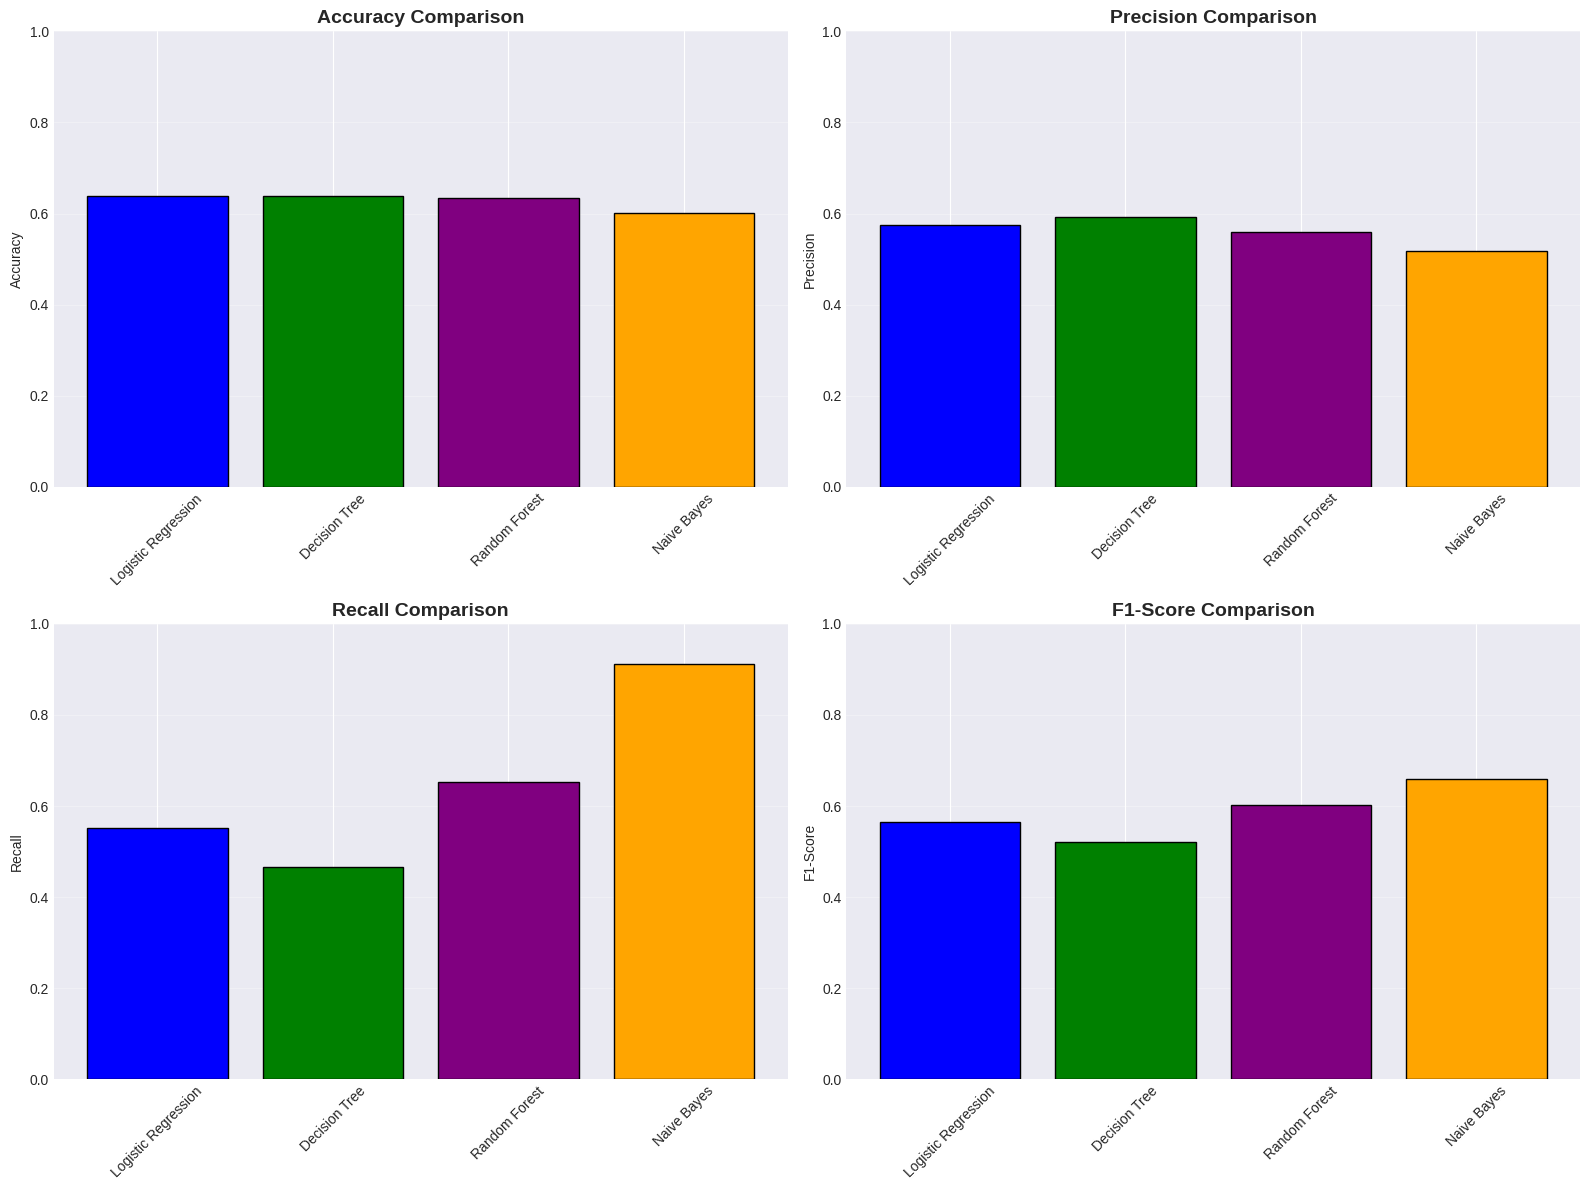

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.bar(model_comparison['Model'], model_comparison[metric],
           color=['blue', 'green', 'purple', 'orange'], edgecolor='black')
    ax.set_title(f'{metric} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


#Key Insights and Recommendations

In [ ]:
print('KEY INSIGHTS:')
print('='*60)

avg_response_by_handler = df.groupby('handled_by')['response_time_min'].mean()
print(f'\n1. Average Response Time:')
print(avg_response_by_handler)

satisfaction_by_handler = df.groupby('handled_by')['customer_satisfaction'].mean()
print(f'\n2. Average Customer Satisfaction:')
print(satisfaction_by_handler)

resolution_rate = df.groupby('resolution_status').size() / len(df) * 100
print(f'\n3. Resolution Status Distribution:')
print(resolution_rate)

cost_by_handler = df.groupby('handled_by')['interaction_cost_usd'].mean()
print(f'\n4. Average Cost per Interaction:')
print(cost_by_handler)

best_model = model_comparison.loc[model_comparison['Accuracy'].idxmax()]
print(f'\n5. Best Performing Model: {best_model["Model"]} (Accuracy: {best_model["Accuracy"]:.4f})')

KEY INSIGHTS:

1. Average Response Time:
handled_by
AI Chatbot     1.506227
Human Agent    7.045356
Name: response_time_min, dtype: float64

2. Average Customer Satisfaction:
handled_by
AI Chatbot     3.312866
Human Agent    3.260250
Name: customer_satisfaction, dtype: float64

3. Resolution Status Distribution:
resolution_status
Escalated    17.94
Pending       7.25
Resolved     74.81
dtype: float64

4. Average Cost per Interaction:
handled_by
AI Chatbot     3.007827
Human Agent    6.997386
Name: interaction_cost_usd, dtype: float64

5. Best Performing Model: Logistic Regression (Accuracy: 0.6380)


## Summary

This analysis provides comprehensive insights into customer service interactions:

### Data Overview
- Analyzed 10,000 customer service interactions
- Examined 13 features including response time, satisfaction, sentiment, and costs

### Key Findings
- AI Chatbots handle interactions faster than human agents
- Customer satisfaction varies by query type and resolution status
- Response time is a significant predictor of customer satisfaction

### Model Performance
- Multiple classification models were trained and evaluated
- Random Forest and Logistic Regression showed strong performance
- Feature importance analysis revealed key drivers of satisfaction

### Recommendations
- Optimize response times for escalated cases
- Improve AI chatbot handling of complex queries
- Focus on query types with lower satisfaction scores
- Monitor and reduce interaction costs while maintaining quality
